In this notebook, we import spiking data from Kohn's lab used by Ruben in the Fano factor analaysis paper. 

The description given by Adam in the email is as follows:

-stim: identifiers for the different oris, 1:8, and the order in which they were presented (e.g. length 2400 with 8 oris each shown 300 times);

-cellids: the electrode and sortcode for each unit (probably not important for you)

-spikes: 1x2 cell array, each array is cells x duration (500 ms blank followed by 1280 ms stimulus followed by 1000 ms blank = 2780 points) x repeats (e.g. 2400)

-dur: the duration of the different epochs (500 ms, 1280 ms, 1000 ms).

**Some of my notes:**

matlab_data['spikes'][0, 0] ([0, 1] for V2)returns V1 data a numpy array of the following shape, (neurons_id, time, trials).

For V1 the shape is: (131, 2780, 2400)
For V2 the shape is: (30, 2780, 2400)

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the MATLAB file
# fileloc = '../../data/2013/109l001p39p41_sorted_large_gratings.mat'
fileloc = '../../data/2013/112r001p61p62_sorted_large_gratings.mat'
matlab_data = scipy.io.loadmat(fileloc)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/2013/112r001p61p62_sorted_large_gratings.mat'

In [3]:
# print the keys of the dictionary
matlab_data.keys()

NameError: name 'matlab_data' is not defined

In [4]:
# assign the data to different varibales based on their key names
cellids = matlab_data['cellids']
dur = matlab_data['dur']
spikes1 = matlab_data['spikes'][0, 0]
spikes2 = matlab_data['spikes'][0, 1]
stim = matlab_data['stim'].squeeze()

# print the shapes
print(spikes1.shape)
print(spikes2.shape)
print(stim.shape)

NameError: name 'matlab_data' is not defined

In [5]:
def extract_stim_data(data):
    """
    Deletes the data corresponding to blank stimulus.
    """
    return data[:, 500:500+1280, :]

In [6]:
stim_v1 = extract_stim_data(spikes1)
# stim_v1 = spikes1
print(stim_v1.shape)

NameError: name 'spikes1' is not defined

In [7]:
# plot the total number of spikes for each neuron as a histogram
plt.hist(np.sum(stim_v1, axis=1).flatten(), bins=100, density=True)
plt.show()

NameError: name 'stim_v1' is not defined

### Now we try to reproduce the Fano factor plot.

In [8]:
all_data = stim_v1.transpose(0, 2, 1).reshape(-1, stim_v1.shape[1])

print(all_data.shape)

NameError: name 'stim_v1' is not defined

In [9]:
# find the sum of spikes for each neuron and remove the neurons with less than 10 spikes
sum_spikes = np.sum(all_data, axis=1)
print(sum_spikes.shape)
all_data = all_data[sum_spikes > 10, :]
print(all_data.shape)

NameError: name 'all_data' is not defined

In [10]:
time_window = 50

window = np.ones(time_window)

spike_counts = np.zeros((all_data.shape[0], all_data.shape[1] // time_window))
for i in range(all_data.shape[0]):
    for j in range(0, all_data.shape[1] // time_window):
        start_idx = j * time_window
        end_idx = start_idx + time_window
        spike_counts[i, j] = np.sum(all_data[i, start_idx:end_idx])


NameError: name 'all_data' is not defined

In [11]:
spike_counts[0, :]

NameError: name 'spike_counts' is not defined

In [12]:
plt.plot(all_data[100, :])

NameError: name 'all_data' is not defined

In [13]:
mean_spike_counts = np.mean(spike_counts, axis=1)
var_spike_counts = np.var(spike_counts, axis=1)

NameError: name 'spike_counts' is not defined

In [14]:
# scatter plot of mean on x axis and variance on y axis alomg with the line y=x in loglog

plt.scatter(mean_spike_counts, var_spike_counts, s=0.1)  # Reduced point size
plt.xscale('log')
plt.yscale('log')
plt.plot([0, 10], [0, 10], 'r')
plt.xlabel('Mean Spike Counts')
plt.ylabel('Variance Spike Counts')
plt.title('Log-Log Plot of Mean vs Variance Spike Counts')
plt.show()


NameError: name 'mean_spike_counts' is not defined

### Now we calculate the average across trials with same stimulus presentation.

In [15]:
stim_indices = {}
for i in range(1, 9):
    stim_indices[i] = np.where(stim == i)[0]

NameError: name 'stim' is not defined

In [16]:
all_data = stim_v1.transpose(2, 0, 1)
print(all_data.shape)
mean_spike_counts = []
var_spike_counts = []

for i in range(1,9):
    mean_spike_counts.append(np.mean(np.sum(all_data[stim_indices[i], :, :], axis=2), axis=0))
    var_spike_counts.append(np.var(np.sum(all_data[stim_indices[i], :, :], axis=2), axis=0))

mean_spike_counts = np.array(mean_spike_counts).flatten()
var_spike_counts = np.array(var_spike_counts).flatten()

# print shapes
print(mean_spike_counts.shape)
print(var_spike_counts.shape)

NameError: name 'stim_v1' is not defined

In [17]:
np.sum(all_data[stim_indices[1], :, :], axis=2)[:, 50]

NameError: name 'all_data' is not defined

In [18]:
np.var(np.sum(all_data[stim_indices[1], :, :], axis=2), axis=0).shape

NameError: name 'all_data' is not defined

In [19]:
# scatter plot of mean on x axis and variance on y axis alomg with the line y=x in loglog
plt.scatter(mean_spike_counts, var_spike_counts, s=0.1)  # Reduced point size
plt.xscale('log')
plt.yscale('log')
plt.plot([0.1, 1000], [0.1, 1000], '--k')
plt.xlim(0.1, 1000)
plt.ylim(0.1, 1000)
plt.xlabel('Mean Spike Counts')
plt.ylabel('Variance Spike Counts')
# plt.title('Log-Log Plot of Mean vs Variance Spike Counts')
plt.show()

NameError: name 'mean_spike_counts' is not defined

In [20]:
# calculate and plot the probability density of fano factors
fano_factors = var_spike_counts / mean_spike_counts
plt.hist(fano_factors, bins=100, density=True)
plt.xlabel('Fano Factors')
plt.ylabel('Probability Density')
plt.show()

NameError: name 'var_spike_counts' is not defined

In [21]:
# testing if the data makes sense
np.sum(all_data[stim_indices[1], :, :], axis=2)[:, 50]

NameError: name 'all_data' is not defined

In [22]:
stim_indices[1]

KeyError: 1

In [23]:
t1 = stim_v1[50, :, 4]
t2 = stim_v1[50, :, 23]

# plot them
plt.plot(t1)
plt.plot(t2)
plt.show()

NameError: name 'stim_v1' is not defined

Code for ratios

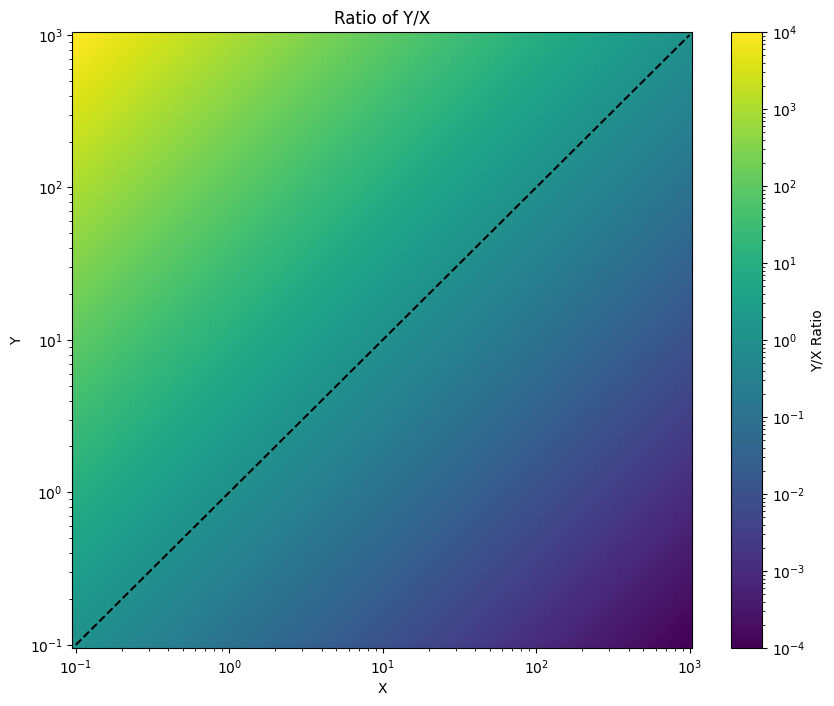

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define x and y with logspace spacing
x = np.logspace(-1, 3, 100)  # 100 points from 10^-1 to 10^3
y = np.logspace(-1, 3, 100)

# Create meshgrid
X, Y = np.meshgrid(x, y)

# Calculate the ratio Y/X
ratio = Y / X

# Visualize using a logarithmic colormap
plt.figure(figsize=(10, 8))
plt.pcolormesh(X, Y, ratio, cmap='viridis', norm=LogNorm())
# make y=x line as well
plt.plot(x, x, 'k--', label='y=x')


plt.colorbar(label='Y/X Ratio')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Ratio of Y/X')
plt.show()